In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set nice display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [8]:
import pandas as pd
import json

# Load YouTube dataset
df = pd.read_csv(r"E:\.NET Task - Youtube Categorizer\Claude\YouTube Categorizer\YouTubeCategorizer\ML_Model\data\USvideos.csv",
                 encoding='utf-8',
                 on_bad_lines='skip')

# Load category mapping
with open(r"E:\.NET Task - Youtube Categorizer\Claude\YouTube Categorizer\YouTubeCategorizer\ML_Model\data\US_category_id.json", 'r', encoding='utf-8') as f:
    categories_json = json.load(f)

print(f"✅ Dataset loaded: {len(df):,} videos")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()



✅ Dataset loaded: 40,949 videos
Columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']

First few rows:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [9]:
# Create ID to category name mapping
id_to_category = {
    int(cat['id']): cat['snippet']['title'] 
    for cat in categories_json['items']
}

# Add category names to dataframe
df['category_name'] = df['category_id'].map(id_to_category)

print("✅ Categories mapped!")
print(f"\nAvailable categories:")
for cat_id, cat_name in sorted(id_to_category.items()):
    count = len(df[df['category_id'] == cat_id])
    print(f"  {cat_name}: {count:,} videos")


✅ Categories mapped!

Available categories:
  Film & Animation: 2,345 videos
  Autos & Vehicles: 384 videos
  Music: 6,472 videos
  Pets & Animals: 920 videos
  Sports: 2,174 videos
  Short Movies: 0 videos
  Travel & Events: 402 videos
  Gaming: 817 videos
  Videoblogging: 0 videos
  People & Blogs: 3,210 videos
  Comedy: 3,457 videos
  Entertainment: 9,964 videos
  News & Politics: 2,487 videos
  Howto & Style: 4,146 videos
  Education: 1,656 videos
  Science & Technology: 2,401 videos
  Nonprofits & Activism: 57 videos
  Movies: 0 videos
  Anime/Animation: 0 videos
  Action/Adventure: 0 videos
  Classics: 0 videos
  Comedy: 0 videos
  Documentary: 0 videos
  Drama: 0 videos
  Family: 0 videos
  Foreign: 0 videos
  Horror: 0 videos
  Sci-Fi/Fantasy: 0 videos
  Thriller: 0 videos
  Shorts: 0 videos
  Shows: 57 videos
  Trailers: 0 videos


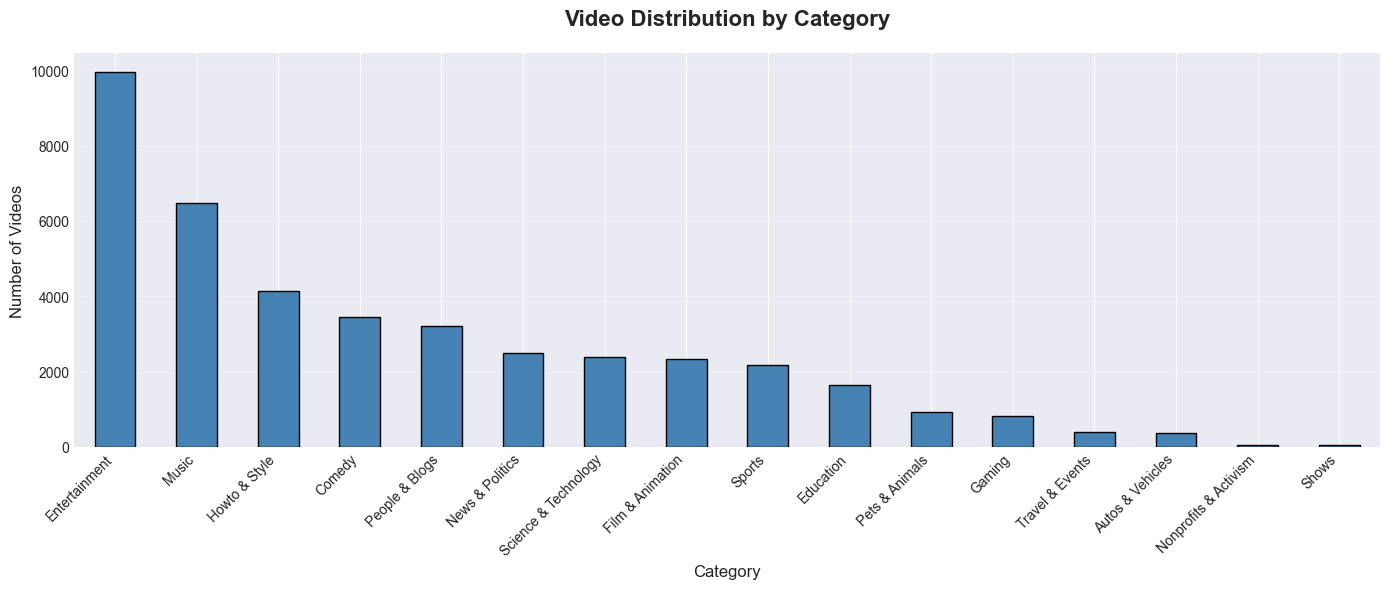

✅ Chart saved: E:\.NET Task - Youtube Categorizer\Claude\YouTube Categorizer\YouTubeCategorizer\ML_Model\data\category_distribution.png


In [12]:
import matplotlib.pyplot as plt
from pathlib import Path

# Set the data folder
data_dir = Path(r"E:\.NET Task - Youtube Categorizer\Claude\YouTube Categorizer\YouTubeCategorizer\ML_Model\data")
output_file = data_dir / "category_distribution.png"

# Create bar chart
plt.figure(figsize=(14, 6))
category_counts = df['category_name'].value_counts()
category_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Video Distribution by Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Chart saved: {output_file}")


In [13]:
# Show sample from each category
print("Sample video from each category:\n" + "="*80)
for category in df['category_name'].unique()[:5]:
    sample = df[df['category_name'] == category].iloc[0]
    print(f"\nCategory: {category}")
    print(f"Title: {sample['title'][:70]}...")
    print(f"Description: {str(sample['description'])[:100]}...")
    print("-"*80)

Sample video from each category:

Category: People & Blogs
Title: WE WANT TO TALK ABOUT OUR MARRIAGE...
Description: SHANTELL'S CHANNEL - https://www.youtube.com/shantellmartin\nCANDICE - https://www.lovebilly.com\n\n...
--------------------------------------------------------------------------------

Category: Entertainment
Title: The Trump Presidency: Last Week Tonight with John Oliver (HBO)...
Description: One year after the presidential election, John Oliver discusses what we've learned so far and enlist...
--------------------------------------------------------------------------------

Category: Comedy
Title: Racist Superman | Rudy Mancuso, King Bach & Lele Pons...
Description: WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► https://www.youtube.com/channel/UC5jkXpfnBhlDjqh0ir5FsIQ?s...
--------------------------------------------------------------------------------

Category: Science & Technology
Title: 2 Weeks with iPhone X...
Description: Using the iPhone for the past two weeks -- he